# Module 2 — Feature Extractor

Extracts **statistical features** from an image that describe its "quality state":

| Feature | Description | Range |
|---|---|---|
| `mean` | Average pixel intensity | 0–1 |
| `std` | Standard deviation (≈ contrast) | 0–1 |
| `entropy` | Shannon entropy of histogram | 0–∞ |
| `dark_ratio` | Fraction of pixels < 0.3 | 0–1 |
| `hist` | Normalised 256-bin histogram | array |

These features become the **260-d input vector** to the CNN.

---


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy as scipy_entropy
from config import Config

print("Imports successful.")

Imports successful.


In [19]:
#feature extraction

def extract_features(image: np.ndarray) -> dict:
   
    # Normalise to float [0, 1]
    if image.dtype == np.uint8:
        img = image.astype(np.float32) / 255.0
    else:
        img = image.astype(np.float32)
        if img.max() > 1.0:
            img /= 255.0

    #Convert to grayscale if RGB
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    #Basic statistics 
    mean_val = float(np.mean(img))
    std_val  = float(np.std(img))

    # Histogram (256 bins, normalised so it sums to 1)
    hist, _ = np.histogram(img, bins=256, range=(0.0, 1.0))
    hist_norm = hist.astype(np.float32) / (hist.sum() + 1e-8)

    #Shannon entropy
    # High entropy → rich texture (many distinct intensities)
    # Low entropy  → flat / uniform image
    entropy_val = float(scipy_entropy(hist_norm + 1e-8))

    #Tonal ratios 
    dark_ratio   = float(np.mean(img < 0.3))
    bright_ratio = float(np.mean(img > 0.7))

    return {
        "mean":         mean_val,
        "std":          std_val,
        "entropy":      entropy_val,
        "hist":         hist_norm,
        "dark_ratio":   dark_ratio,
        "bright_ratio": bright_ratio,
    }


def features_to_vector(features: dict) -> np.ndarray:
    """
    Flatten feature dict into a 1-D numpy array for CNN input.
    Output shape: (260,)  →  4 scalar stats + 256 histogram bins
    """
    scalars = np.array([
        features["mean"],
        features["std"],
        features["entropy"],
        features["dark_ratio"],
    ], dtype=np.float32)

    return np.concatenate([scalars, features["hist"]])  # shape (260,)


print("Feature extraction functions defined.")

Feature extraction functions defined.


In [20]:
# extract features from a synthetic image

# Create three test images with different characteristics
np.random.seed(42)
dark_img   = np.random.randint(0,  80,  (128, 128), dtype=np.uint8)  # dark
bright_img = np.random.randint(180, 255,(128, 128), dtype=np.uint8)  # bright
normal_img = np.random.randint(80,  180,(128, 128), dtype=np.uint8)  # normal

for name, img in [("Dark", dark_img), ("Bright", bright_img), ("Normal", normal_img)]:
    f   = extract_features(img)
    vec = features_to_vector(f)
    print(f"[{name:6s}]  mean={f['mean']:.3f}  std={f['std']:.3f}  "
          f"entropy={f['entropy']:.3f}  dark_ratio={f['dark_ratio']:.3f}  "
          f"vec_shape={vec.shape}")

[Dark  ]  mean=0.154  std=0.090  entropy=4.379  dark_ratio=0.964  vec_shape=(260,)
[Bright]  mean=0.851  std=0.085  entropy=4.315  dark_ratio=0.000  vec_shape=(260,)
[Normal]  mean=0.508  std=0.113  entropy=4.602  dark_ratio=0.000  vec_shape=(260,)


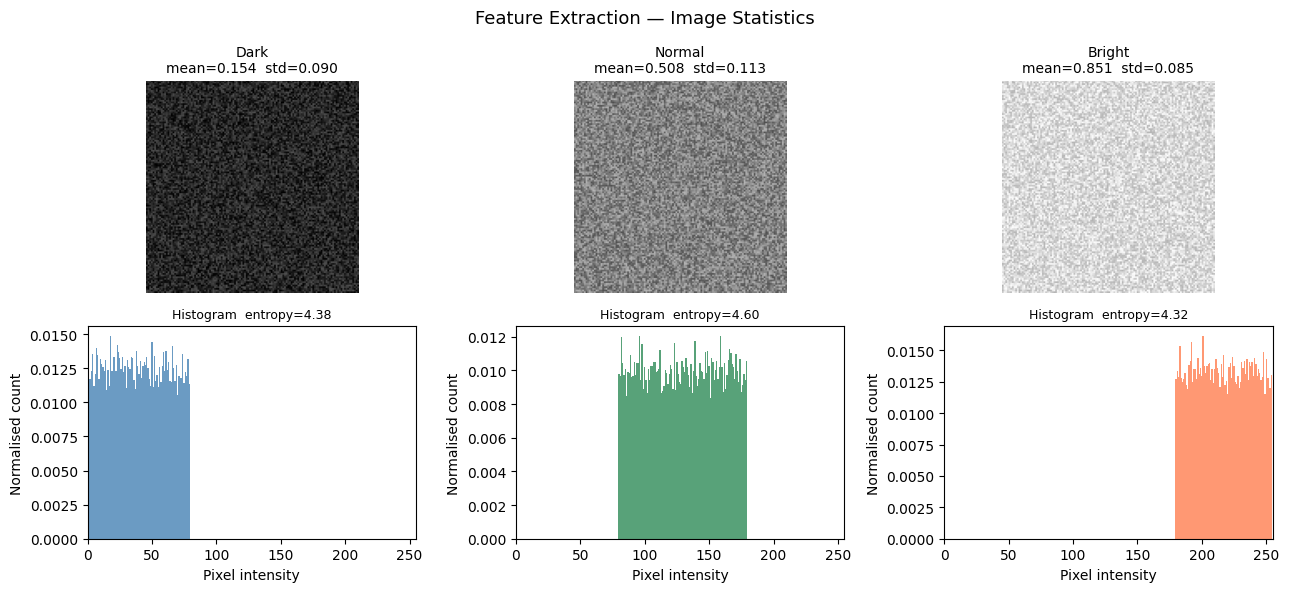

✅ Saved feature_extraction_demo.png


In [21]:
# Visualise: image + histogram for each type

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
images = [("Dark", dark_img, "steelblue"),
          ("Normal", normal_img, "seagreen"),
          ("Bright", bright_img, "coral")]

for col, (name, img, color) in enumerate(images):
    feats = extract_features(img)

    # Image
    axes[0, col].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(f"{name}\nmean={feats['mean']:.3f}  std={feats['std']:.3f}",
                           fontsize=10)
    axes[0, col].axis("off")

    # Histogram
    axes[1, col].bar(range(256), feats["hist"], color=color, alpha=0.8, width=1)
    axes[1, col].set_xlim(0, 255)
    axes[1, col].set_xlabel("Pixel intensity")
    axes[1, col].set_ylabel("Normalised count")
    axes[1, col].set_title(f"Histogram  entropy={feats['entropy']:.2f}", fontsize=9)

plt.suptitle("Feature Extraction — Image Statistics", fontsize=13)
plt.tight_layout()
plt.savefig("feature_extraction_demo.png", dpi=120)
plt.show()
print("✅ Saved feature_extraction_demo.png")

In [22]:
# ── Save module to disk for other notebooks ───────────────────────────────────

source = '''
import cv2, numpy as np
from scipy.stats import entropy as scipy_entropy

def extract_features(image):
    if image.dtype == np.uint8:
        img = image.astype(np.float32) / 255.0
    else:
        img = image.astype(np.float32)
        if img.max() > 1.0: img /= 255.0
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mean_val = float(np.mean(img))
    std_val  = float(np.std(img))
    hist, _  = np.histogram(img, bins=256, range=(0.0, 1.0))
    hist_norm = hist.astype(np.float32) / (hist.sum() + 1e-8)
    entropy_val  = float(scipy_entropy(hist_norm + 1e-8))
    dark_ratio   = float(np.mean(img < 0.3))
    bright_ratio = float(np.mean(img > 0.7))
    return {"mean": mean_val, "std": std_val, "entropy": entropy_val,
            "hist": hist_norm, "dark_ratio": dark_ratio, "bright_ratio": bright_ratio}

def features_to_vector(features):
    scalars = np.array([features["mean"], features["std"],
                        features["entropy"], features["dark_ratio"]], dtype=np.float32)
    return np.concatenate([scalars, features["hist"]])
'''

with open("feature_extractor.py", "w") as f:
    f.write(source)

print("feature_extractor.py written to disk.")

feature_extractor.py written to disk.
